In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

In [37]:
df=pd.read_csv("/Users/melodyqian/Documents/GitHub/FindMyNuclearWaste/data/MLDataset.csv")
dummydf = pd.get_dummies(df, columns=['Urban_Rural'], drop_first=True)
dummydf= dummydf[dummydf['house_value_median']>0]
dummydf=dummydf[dummydf['county_data']==0]
collinear= ['household_income_median','nonhispanic_percent', 'white_percent','femalepercent','missing_race','county_data', 'index']
dummydf = dummydf.drop(columns=collinear, axis=1)
#print(dummydf)


cont_cols = ['occupied_percent' ,'house_value_median', 'age_median', 'malepercent', 'hispanic_percent', 'black_percent', 'asian_percent', 'pacific_percent','native_percent', 'median_family_percent']  # numeric feature names
bin_cols = ['Urban_Rural_Rural', 'Urban_Rural_Urban']  # categorical feature names

pre = ColumnTransformer([
    ("num", StandardScaler(), cont_cols),   # scale continuous only
    ("bin", "passthrough", bin_cols),       # leave 0/1 as-is
])

model = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(max_iter=2000, penalty="l2"))  # or penalty="l1" for L1
])

In [38]:
#plt.figure(figsize = (10, 10))
#sns.heatmap(dummydf.corr(), annot = True)

In [49]:
y = dummydf['site']                     # categorical
X = dummydf.drop(columns=['site'])

clf = LogisticRegression(
    penalty="l1", solver="liblinear", max_iter=2000, C=1.0, random_state=42
)

model = Pipeline([("pre", pre), ("clf", clf)])

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="accuracy")

print(f"CV accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

model.fit(X_tr, y_tr)
y_pred = model.predict(X_te)

CV accuracy: 0.910 ± 0.057


In [42]:
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
model = Pipeline([("pre", pre), ("model", lasso)])

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="r2")
print(f"CV R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


CV R²: 0.035 ± 0.510


In [48]:
model.fit(X_tr, y_tr)
y_pred = model.predict(X_te)
print("Holdout R²:", r2_score(y_te, y_pred))
print("Chosen alpha:", model.named_steps["model"].alpha_)

Holdout R²: 0.3060924123807488
Chosen alpha: 0.030897575328646374


In [34]:
imp = SimpleImputer(strategy="median")
X_train_num = imp.fit_transform(X_train)   # learn medians from train
X_test_num  = imp.transform(X_test)        # apply same medians to test

# 2) Scale numerics (fit on train only)
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train_num)
X_test_scaled  = sc.transform(X_test_num)

# 3) Lasso with CV chooses alpha fairly (now that scales are comparable)
lasso = LassoCV(cv=5, random_state=0, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
print("Best alpha:", lasso.alpha_)
print("Holdout R^2:", r2_score(y_test, lasso.predict(X_test_scaled)))

Best alpha: 0.04669911426328935
Holdout R^2: 0.37020628543375245


In [30]:
import numpy as np
print("Overall class balance:", np.mean(y))            # fraction of 1s
print("Head 50 balance:", np.mean(y[:50]))
print("Tail 50 balance:", np.mean(y[-50:]))


Overall class balance: 0.5909090909090909
Head 50 balance: 1.0
Tail 50 balance: 0.1


In [7]:

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)


Lasso()

In [8]:
train_score_ls = lasso.score(X_train, y_train)
test_score_ls = lasso.score(X_test, y_test)

print("The train score for ls model is {}".format(train_score_ls))
print("The test score for ls model is {}".format(test_score_ls))

The train score for ls model is 0.30288570250475455
The test score for ls model is 0.3894721691140166


In [9]:
lasso_cv = LassoCV(alphas=[0.001, 0.01, 0.1, 1.0, 10.0], cv=5)
lasso_cv.fit(X_train, y_train)

LassoCV(alphas=[0.001, 0.01, 0.1, 1.0, 10.0], cv=5)

In [10]:
print(f"Best alpha: {lasso_cv.alpha_}")
print(f"Train score: {lasso_cv.score(X_train, y_train)}")
print(f"Test score: {lasso_cv.score(X_test, y_test)}")

Best alpha: 0.001
Train score: 0.480302756063693
Test score: 0.44228757868213175


In [11]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
print(f"LR train: {lr.score(X_train, y_train)}")
print(f"LR test: {lr.score(X_test, y_test)}")

LR train: 0.5119077518889781
LR test: 0.30733826318144175


In [28]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
print(f"RF train: {rf.score(X_train, y_train)}")
print(f"RF test: {rf.score(X_test, y_test)}")

RF train: 0.9662807692307692
RF test: 0.7719897435897436


NameError: name 'cross_val_score' is not defined

                  Feature  Importance
1      house_value_median    0.785285
3             malepercent    0.069319
0        occupied_percent    0.050985
5           black_percent    0.020382
4        hispanic_percent    0.018515
9   median_family_percent    0.017058
7         pacific_percent    0.015753
6           asian_percent    0.014875
2              age_median    0.006425
8          native_percent    0.001402
10      Urban_Rural_Rural    0.000000
11      Urban_Rural_Urban    0.000000


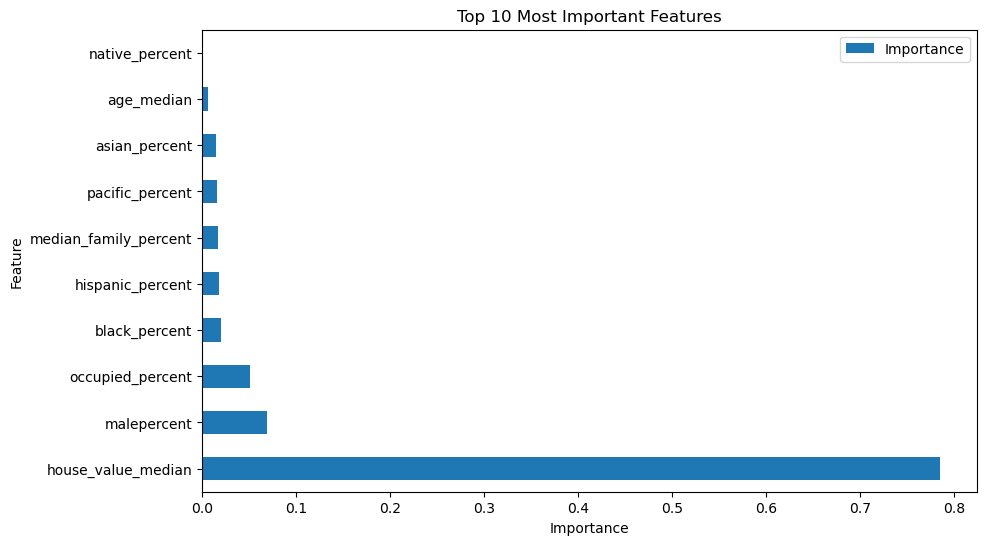